In [ ]:
# Import the dependencies
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, recall_score, roc_curve
import joblib
import matplotlib.pyplot as plt

In [ ]:
# Load the dataset
df = pd.read_csv('../data/bank_final.csv')

print(df.shape)

df.head()

(43190, 8)


,duration,poutcome_success_feat,month_dec_oct_sep_mar_feat,pdays_replaced_feat,contact_cellular_telephone_feat,housing_feat,job_student_or_retired_feat,y
0,0.376744,0,0,0.0,0,1,0,0
1,-0.134884,0,0,0.0,0,1,0,0
2,-0.483721,0,0,0.0,0,1,0,0
3,-0.190698,0,0,0.0,0,1,0,0
4,0.172093,0,0,0.0,0,1,0,0


In [ ]:
# Separate X and y
X = df.drop('y', axis = 1)
y = df['y']

In [ ]:
# Split train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.15, random_state = 42, stratify = y
)

In [ ]:
# Train dummy as out base model
dummy = DummyClassifier(strategy = 'uniform', random_state = 42)

dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_test)

print(classification_report(y_test, y_pred_dummy, zero_division = 0))
print(roc_auc_score(y_test, dummy.predict_proba(X_test)[:, 1]))

              precision    recall  f1-score   support

           0       0.89      0.50      0.64      5726
           1       0.12      0.50      0.19       753

    accuracy                           0.50      6479
   macro avg       0.50      0.50      0.42      6479
weighted avg       0.80      0.50      0.59      6479

0.5


In [ ]:
# Logistic Regression
logreg_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2', 'elasticnet'],
    'solver': ['liblinear', 'saga']
}

logreg = LogisticRegression(class_weight = 'balanced', max_iter = 1000, random_state = 42)

skf = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

logreg_gs = GridSearchCV(logreg, logreg_params, cv = skf, scoring = 'recall', n_jobs = -1)

logreg_gs.fit(X_train, y_train)

y_pred_lr = logreg_gs.predict(X_test)
y_prob_lr = logreg_gs.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_lr))
print(roc_auc_score(y_test, y_prob_lr))

/home/erfan/datascience_env/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/erfan/datascience_env/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/erfan/datascience_env/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=

              precision    recall  f1-score   support

           0       0.97      0.83      0.90      5726
           1       0.40      0.82      0.53       753

    accuracy                           0.83      6479
   macro avg       0.68      0.83      0.72      6479
weighted avg       0.91      0.83      0.86      6479

0.896466526489223


/home/erfan/datascience_env/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [ ]:
# Decision Tree
dt_params = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [5, 10, 50, 100],
    'min_samples_leaf': [5, 10, 20, 50],
    'max_features': [None, 'sqrt', 'log2'],
    'class_weight': ['balanced'],
    'ccp_alpha': [0.0, 0.001, 0.01, 0.05]
}

dt = DecisionTreeClassifier(random_state = 42)
dt_gs = GridSearchCV(dt, dt_params, cv = skf, scoring = 'recall', n_jobs = -1)
dt_gs.fit(X_train, y_train)

y_pred_dt = dt_gs.predict(X_test)
y_prob_dt = dt_gs.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_dt))
print(roc_auc_score(y_test, y_prob_dt))

              precision    recall  f1-score   support

           0       0.98      0.69      0.81      5726
           1       0.28      0.91      0.43       753

    accuracy                           0.72      6479
   macro avg       0.63      0.80      0.62      6479
weighted avg       0.90      0.72      0.77      6479

0.8509105967560657


In [ ]:
# Random Forest
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'class_weight': ['balanced', 'balanced_subsample']
}

rf = RandomForestClassifier(random_state = 42, n_jobs = -1)
rf_gs = GridSearchCV(
    rf, rf_params, cv = skf, scoring = 'recall', n_jobs = -1
)
rf_gs.fit(X_train, y_train)

y_pred_rf = rf_gs.predict(X_test)
y_prob_rf = rf_gs.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))
print(roc_auc_score(y_test, y_prob_rf))

              precision    recall  f1-score   support

           0       0.98      0.80      0.88      5726
           1       0.36      0.86      0.51       753

    accuracy                           0.81      6479
   macro avg       0.67      0.83      0.69      6479
weighted avg       0.91      0.81      0.84      6479

0.9060594274433296


In [ ]:
# XGB
neg, pos = np.bincount(y_train)
scale_weight = neg / pos

xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'scale_pos_weight': [scale_weight]
}

xgb = XGBClassifier(random_state = 42, use_label_encoder = False)
xgb_gs = GridSearchCV(xgb, xgb_params, cv = skf, scoring = 'recall', n_jobs = -1)
xgb_gs.fit(X_train, y_train)

y_pred_xgb = xgb_gs.predict(X_test)
y_prob_xgb = xgb_gs.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_xgb))
print(roc_auc_score(y_test, y_prob_xgb))

/home/erfan/datascience_env/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [00:54:34] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/erfan/datascience_env/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [00:54:34] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/erfan/datascience_env/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [00:54:34] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/erfan/datascience_env/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [00:54:34] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fo

              precision    recall  f1-score   support

           0       0.98      0.77      0.87      5726
           1       0.34      0.88      0.49       753

    accuracy                           0.79      6479
   macro avg       0.66      0.83      0.68      6479
weighted avg       0.91      0.79      0.82      6479

0.8952353352917355


/home/erfan/datascience_env/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [00:54:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


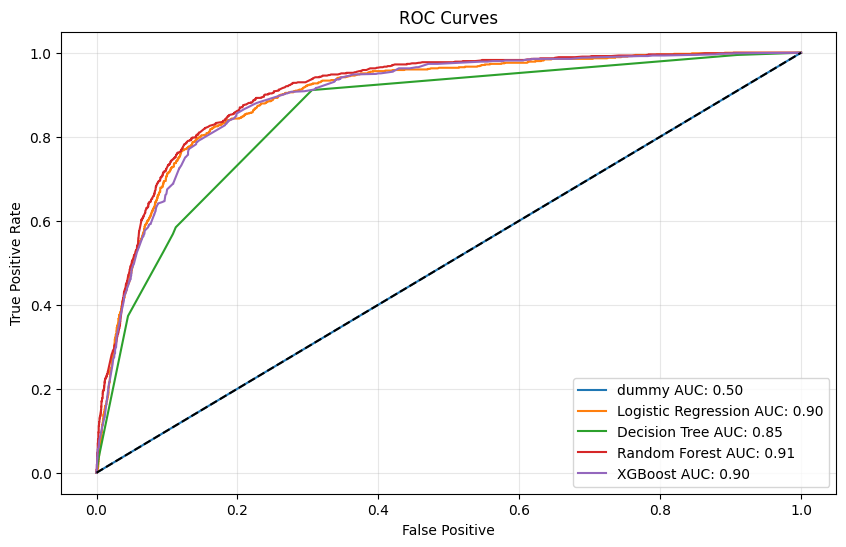

In [ ]:
# Plot all models roc curve
plt.figure(figsize = (10, 6))

models = {
    'dummy': dummy.predict_proba(X_test)[:, 1],
    'Logistic Regression': y_prob_lr,
    'Decision Tree': y_prob_dt,
    'Random Forest': y_prob_rf,
    'XGBoost': y_prob_xgb
    }

for name, probs in models.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label = f'{name} AUC: {roc_auc_score(y_test, probs):.2f}')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.grid(alpha = 0.3)
plt.show()

In [ ]:
# Confusion Matrix for all models
models_cm = {
    'Dummy': dummy,
    'Logistic Regression': logreg_gs,
    'Decision Tree': dt_gs,
    'Random Forest': rf_gs,
    'XGBoost': xgb_gs
}

for name, model in models_cm.items():
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    recall_1 = recall_score(y_test, y_pred, pos_label = 1)

    print(f'---{name}---')
    print(cm)
    print(f'Recall score for class 1: {recall_1:.4f}')

---Dummy---
[[2889 2837]
 [ 374  379]]
Recall score for class 1: 0.5033
---Logistic Regression---
[[4781  945]
 [ 135  618]]
Recall score for class 1: 0.8207
---Decision Tree---
[[3975 1751]
 [  67  686]]
Recall score for class 1: 0.9110
---Random Forest---
[[4581 1145]
 [ 104  649]]
Recall score for class 1: 0.8619
---XGBoost---
[[4434 1292]
 [  91  662]]
Recall score for class 1: 0.8792


In [ ]:
# Save all the models trained
models_to_save = {
    'logreg': logreg_gs.best_estimator_,
    'decision_tree': dt_gs.best_estimator_,
    'random_forest': rf_gs.best_estimator_,
    'xgb': xgb_gs.best_estimator_
}

for name, model in models_to_save.items():
    joblib.dump(model, f'../models/{name}_model.pkl')